Epoch 1/25


/Users/artyomk/dev/projects/market-mind/venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6965
Epoch 2/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6889
Epoch 3/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6847
Epoch 4/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6832
Epoch 5/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6851
Epoch 6/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6840
Epoch 7/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6793
Epoch 8/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6807
Epoch 9/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6811
Epoch 10/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6803
Epoch 11/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6779
Epoch 12/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6730
Epoch 13/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6744
Epoch 14/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6716
Epoch 15/25
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6754
Epoch 16/25
26/

/var/folders/xp/g2yl3tfx515c2l9k7d3jhkyr0000gn/T/ipykernel_1113/2684947576.py:94: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_row_context[0] = pred_scaled  # Replace actual return with predicted return


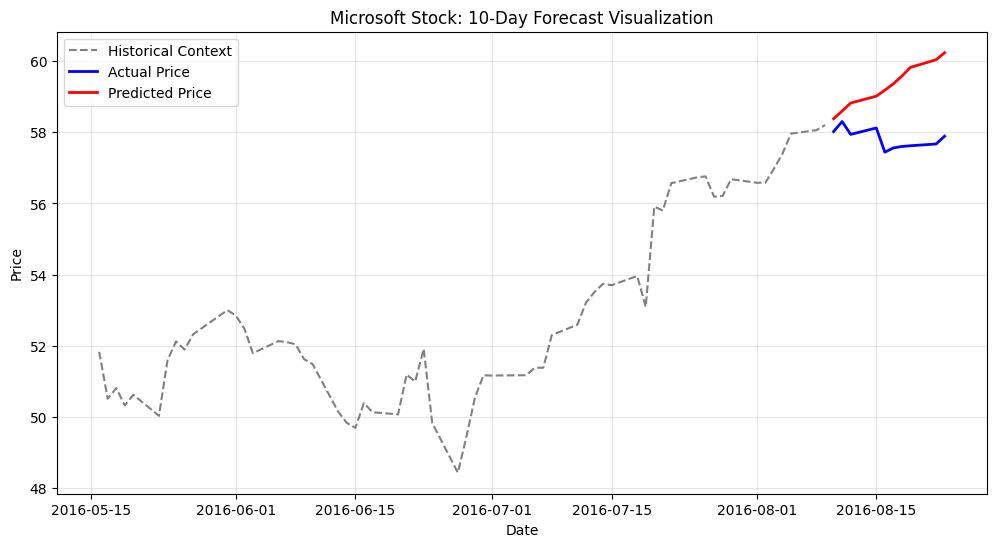

Directional Accuracy: 77.78%


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from tensorflow import keras

# All inputs needed for model: date, close price pairs of stock data

# ==========================================
# 1. DATA LOADING & FEATURE ENGINEERING
# ==========================================
data = pd.read_csv("data/MicrosoftStock.csv")

data['date'] = pd.to_datetime(data['date'])
data['month_sin'] = np.sin(2 * np.pi * data['date'].dt.month / 12)
data['month_cos'] = np.cos(2 * np.pi * data['date'].dt.month / 12)
data['day_sin'] = np.sin(2 * np.pi * data['date'].dt.dayofweek / 7)
data['day_cos'] = np.cos(2 * np.pi * data['date'].dt.dayofweek / 7)

data['vol_pct_change'] = data['volume'].pct_change()
# Using % change (Returns) to make data stationary (prevents trend-following overfitting)
data['return'] = data['close'].pct_change()
# IMPROVEMENT: Add a 5-day Moving Average of returns to give the model "momentum" context
data['return_mavg'] = data['return'].rolling(window=5).mean()

# Drop rows with NaN values created by pct_change and rolling mean
data = data.dropna().reset_index(drop=True)

feature_cols = ['return', 'return_mavg', 'vol_pct_change', 'month_sin', 'month_cos', 'day_sin', 'day_cos']
dataset = data[feature_cols].values

# ==========================================
# 2. DATA SPLITTING & SCALING
# ==========================================
training_data_len = int(np.ceil(len(dataset)) * 0.7)

# Scaler is fitted ONLY on training data to avoid data leakage from the future
scaler = StandardScaler()
scaler.fit(dataset[:training_data_len])

scaled_train = scaler.transform(dataset[:training_data_len])
# For testing, we need the 60 days prior to the test start for the first window
scaled_test_source = scaler.transform(dataset[training_data_len - 60:])

# ==========================================
# 3. SLIDING WINDOW PREPARATION
# ==========================================
X_train, y_train = [], []

for i in range(60, len(scaled_train)):
    X_train.append(scaled_train[i-60:i, :]) # Take all features (return + mavg)
    y_train.append(scaled_train[i, 0])      # Predict only the 'return' (index 0)

X_train, y_train = np.array(X_train), np.array(y_train)

# ==========================================
# 4. MODEL ARCHITECTURE & REGULARIZATION
# ==========================================
model = keras.models.Sequential([
    keras.layers.LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    keras.layers.Dropout(0.3),
    keras.layers.LSTM(64, return_sequences=False),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1) 
])

# IMPROVEMENT: Early Stopping halts training if the model stops improving
early_stop = keras.callbacks.EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

model.compile(optimizer="adam", loss="mae")
model.fit(X_train, y_train, epochs=25, batch_size=32, callbacks=[early_stop], verbose=1)

# ==========================================
# 5. RECURSIVE PREDICTION LOOP (UPDATED)
# ==========================================
# We need to pull the 'actual' values for the other 6 features from the test set
# so the model has valid time/volume context for each prediction step.
scaled_test_data = scaler.transform(dataset[training_data_len:])

current_batch = scaled_test_source[:60].reshape((1, 60, len(feature_cols)))
predicted_returns_scaled = []

for i in range(10):
    # 1. Predict the next day's scaled return
    pred_scaled = model.predict(current_batch, verbose=0)[0]
    predicted_returns_scaled.append(pred_scaled)
    
    # 2. Prepare the new row for the sliding window
    # We take the actual volume/time features for 'tomorrow' from scaled_test_data
    # but we swap the 'return' (index 0) for our predicted value.
    next_row_context = scaled_test_data[i].copy() 
    next_row_context[0] = pred_scaled  # Replace actual return with predicted return
    # Note: return_mavg (index 1) will technically be slightly 'stale' here, 
    # which is a great limitation to mention in your evaluation!
    
    # 3. Slide the window: Drop the oldest day, append the new predicted row
    next_row_reshaped = next_row_context.reshape(1, 1, len(feature_cols))
    current_batch = np.append(current_batch[:, 1:, :], next_row_reshaped, axis=1)

# ==========================================
# 6. PRICE RECONSTRUCTION & VISUALIZATION
# ==========================================
comparison_period = 10 

# Inverse scaling for returns
dummy_scaler = np.zeros((len(predicted_returns_scaled), len(feature_cols)))
dummy_scaler[:, 0] = np.array(predicted_returns_scaled).flatten()
predictions_raw_returns = scaler.inverse_transform(dummy_scaler)[:, 0]

# Price reconstruction
last_actual_price = data['close'].iloc[training_data_len - 1]
reconstructed_prices = []

for ret in predictions_raw_returns:
    next_price = last_actual_price * (1 + ret)
    reconstructed_prices.append(next_price)
    last_actual_price = next_price

# Dataframe for the 10-day window
test_df_subset = data[training_data_len : training_data_len + comparison_period].copy()
test_df_subset['Predictions'] = reconstructed_prices

# --- THE FIX: SPLITTING INTO 3 LINES ---
plt.figure(figsize=(12,6))

# 1. Historical Context (The trend leading up to the test)
# We plot up to training_data_len to show the "past"
plt.plot(data['date'].iloc[training_data_len-60 : training_data_len], 
         data['close'].iloc[training_data_len-60 : training_data_len], 
         label="Historical Context", color='gray', linestyle='--')

# 2. Actual Price (The ground truth during the 10-day window)
plt.plot(test_df_subset['date'], test_df_subset['close'], 
         label="Actual Price", color='blue', linewidth=2)

# 3. Predicted Price (The model's forecast)
plt.plot(test_df_subset['date'], test_df_subset['Predictions'], 
         label="Predicted Price", color='red', linewidth=2)

plt.title("Microsoft Stock: 10-Day Forecast Visualization")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
# ==========================================
# 7. DIRECTIONAL ACCURACY CALCULATION
# ==========================================

# We compare the 'return' (sign of price movement)
# Actual signs: Was the actual price higher than previous day?
actual_returns = test_df_subset['close'].pct_change().dropna()
# Predicted signs: Was the predicted price higher than previous day?
predicted_returns = test_df_subset['Predictions'].pct_change().dropna()

# Check where the signs match (both up or both down)
# np.sign returns 1 for positive, -1 for negative, 0 for no change
correct_directions = np.sign(actual_returns.values) == np.sign(predicted_returns.values)

directional_accuracy = np.mean(correct_directions) * 100

print(f"Directional Accuracy: {directional_accuracy:.2f}%")